# TalentPulse Salary Prediction

## Goal

Build a beginner-friendly machine-learning workflow that predicts annual average salary in USD.

The case-study brief asks us to:

- inspect and clean 4,653 job postings;
- explain how missing salaries are handled;
- create useful features from seniority, experience, and skills;
- compare Linear Regression, Random Forest, and Gradient Boosting;
- tune the best model with 5-fold cross-validation;
- evaluate MAE, RMSE, and R² on an untouched test set;
- check errors by country and job level; and
- make a business recommendation against the legacy MAE of **$18,500**.

> The case-study brief is treated as project reference material. The code below is the implementation.

## What this revised notebook fixes

The earlier notebook had useful cleaning and diagnostic work, but it ended before the project was complete. This version:

1. actually continues with the deduplicated dataframe;
2. keeps missing salaries out of model training instead of imputing the target;
3. prevents salary-derived features from leaking the answer into the model;
4. compares the required regression algorithms;
5. shows where hyperparameter tuning is required;
6. evaluates the final model once on an untouched test set; and
7. produces residual, segment, and benchmark results plus a prediction file.

## 1. Setup

The notebook first imports the libraries and fixes the random seed so that results can be reproduced.

In [1]:
from pathlib import Path
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
LEGACY_MAE = 18_500
INDUSTRY_MAE = 8_000

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid")

In [2]:
# The first path makes the notebook portable when the CSV is beside it.
# The second path lets this revised copy run from the current workspace.
data_candidates = [
    Path.cwd() / "jobs_dataset.csv",
    Path(r"C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project\jobs_dataset.csv"),
]

DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place jobs_dataset.csv in the same folder as this notebook.")

OUTPUT_DIR = Path.cwd() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

raw = pd.read_csv(DATA_PATH)
print(f"Data source: {DATA_PATH}")
print(f"Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}")
display(raw.head())

Data source: C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project\jobs_dataset.csv
Rows: 4,653 | Columns: 17


,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,experience_required,degree_required,skills,num_skills,job_level,is_remote,salary_avg,has_salary
0,5710345523,data scientist,Empnéo ICT,India,NaN,NaN,Job description Lead Data Scientist — Analytic...,India,data scientist,8.00,Not specified,[],0,Mid,False,NaN,False
1,5676535670,data scientist,ADM,"Bangalore, Karnataka",NaN,NaN,"Data Scientist Bengaluru, India Position Summa...",India,data scientist,NaN,Not specified,[],0,Mid,False,NaN,False
2,5705677339,data scientist,v4c.ai,India,NaN,NaN,Overview: The Data Scientist supports the deve...,India,data scientist,NaN,Not specified,['machine learning'],1,Mid,False,NaN,False
3,5689758521,data scientist,Kotak Mahindra Bank,"Bangalore, Karnataka",NaN,NaN,Hiring for Data Scientist Role Work location: ...,India,data scientist,10.00,Not specified,[],0,Mid,False,NaN,False
4,5709942304,data scientist,Whitefield Careers,"Bangalore, Karnataka",NaN,NaN,Data Scientist Location: Bangalore Experience:...,India,data scientist,4.00,Not specified,['machine learning'],1,Mid,False,NaN,False


## 2. Inspect the data

We check column types, missing values, and category counts before changing anything. The target is `salary_avg`.

In [3]:
expected_columns = [
    "job_id", "job_title", "company", "location", "salary_min",
    "salary_max", "description", "country", "search_keyword",
    "experience_required", "degree_required", "skills", "num_skills",
    "job_level", "is_remote", "salary_avg", "has_salary",
]

missing_columns = sorted(set(expected_columns) - set(raw.columns))
assert not missing_columns, f"Missing required columns: {missing_columns}"

quality_summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_count": raw.isna().sum(),
    "missing_pct": raw.isna().mean().mul(100).round(2),
    "unique_values": raw.nunique(dropna=False),
}).sort_values("missing_pct", ascending=False)

display(quality_summary)
print("Countries:", sorted(raw["country"].dropna().unique()))
print("Job levels:", sorted(raw["job_level"].dropna().unique()))

,dtype,missing_count,missing_pct,unique_values
experience_required,float64,4166,89.53,43
salary_max,float64,2358,50.68,1832
salary_avg,float64,2354,50.59,1901
salary_min,float64,2354,50.59,1825
company,object,1,0.02,1852
job_id,int64,0,0.00,4653
skills,object,0,0.00,51
is_remote,bool,0,0.00,2
job_level,object,0,0.00,4
num_skills,int64,0,0.00,6


Countries: ['Australia', 'Canada', 'India', 'UK', 'USA']
Job levels: ['Junior', 'Lead', 'Mid', 'Senior']


### Missing salary decision

Rows without `salary_avg` cannot train a supervised model because the correct answer is unknown. We therefore:

- keep rows with a valid salary as the **training table**;
- keep rows without salary as a separate **scoring pool**; and
- never fill a missing target with the median, because that would invent labels and teach the model artificial salaries.

Missing predictor values are different: they may be imputed inside the model pipeline using training data only.

## 3. Clean text and duplicates

The duplicate check uses the main advertisement content. Conflicting repeated postings are saved for review. Non-conflicting repeats are reduced to one row.

In [4]:
df = raw.copy()

text_columns = df.select_dtypes(include=["object", "string"]).columns
for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

duplicate_key = ["job_title", "company", "location", "country", "description"]
repeated = df.duplicated(subset=duplicate_key, keep=False)

# A repeated group is conflicting only when it contains different known values.
grouped = df.groupby(duplicate_key, dropna=False)
salary_conflict = grouped["salary_avg"].transform(
    lambda values: values.dropna().nunique() > 1
)
level_conflict = grouped["job_level"].transform(
    lambda values: values.dropna().nunique() > 1
)
remote_conflict = grouped["is_remote"].transform(
    lambda values: values.dropna().nunique() > 1
)

conflict_mask = repeated & (salary_conflict | level_conflict | remote_conflict)
duplicate_review = df.loc[conflict_mask].copy()

# Prefer the row containing a salary when otherwise identical rows exist.
dedup_work = df.loc[~conflict_mask].copy()
dedup_work["_salary_present"] = dedup_work["salary_avg"].notna()

df = (
    dedup_work
    .sort_values("_salary_present", ascending=False)
    .drop_duplicates(subset=duplicate_key, keep="first")
    .sort_index()
    .drop(columns="_salary_present")
    .copy()
)

assert not df.duplicated(subset=duplicate_key).any()

print(f"Possible repeated rows: {repeated.sum():,}")
print(f"Conflicting rows saved for review: {len(duplicate_review):,}")
print(f"Rows after duplicate handling: {len(df):,}")

Possible repeated rows: 75
Conflicting rows saved for review: 35
Rows after duplicate handling: 4,597


## 4. Clean and standardize salary

Salary values must be positive and comparable across countries. The source data appears to use local currencies, so fixed 2024 conversion rates are used to create a common USD target.

Very small converted salaries can indicate hourly/monthly values or entry errors. They are flagged rather than silently treated as normal annual salaries. The conservative rule below excludes only values below $1,000 from model training. Values below $10,000 are also reported for business review because a single global cutoff could wrongly remove legitimate lower-paid markets.

In [5]:
salary_columns = ["salary_min", "salary_avg", "salary_max"]
for column in salary_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

non_positive_salary = df[salary_columns].le(0).any(axis=1)
df.loc[non_positive_salary, salary_columns] = np.nan

currency_table = {
    "USA": ("USD", 1.00),
    "UK": ("GBP", 0.78),
    "Canada": ("CAD", 1.37),
    "India": ("INR", 83.67),
    "Australia": ("AUD", 1.52),
}

df["currency"] = df["country"].map(lambda value: currency_table[value][0])
df["local_currency_per_usd"] = df["country"].map(
    lambda value: currency_table[value][1]
)

for column in salary_columns:
    df[f"{column}_reported"] = df[column]
    df[f"{column}_usd"] = df[column] / df["local_currency_per_usd"]

df["salary_unit_suspect"] = (
    df["salary_avg_usd"].notna() & df["salary_avg_usd"].lt(1_000)
)
df["salary_below_10k_review"] = (
    df["salary_avg_usd"].notna() & df["salary_avg_usd"].lt(10_000)
)

# Suspect targets are removed, but their job rows remain available for review/scoring.
df.loc[df["salary_unit_suspect"], "salary_avg_usd"] = np.nan
df["has_salary"] = df["salary_avg_usd"].notna()

print(f"Rows with non-positive salary components: {non_positive_salary.sum():,}")
print(f"Targets below $1,000 excluded: {df['salary_unit_suspect'].sum():,}")
print(f"Targets below $10,000 requiring review: {df['salary_below_10k_review'].sum():,}")

Rows with non-positive salary components: 11
Targets below $1,000 excluded: 11
Targets below $10,000 requiring review: 32


## 5. Feature engineering

We create features that are available before a salary is predicted:

- skill flags from the text-formatted skills list;
- an experience band and a missing-experience flag;
- a senior/premium segment for reporting.

`salary_range_usd` is calculated only for EDA. It is **not** a model feature because it comes from `salary_min` and `salary_max`, which also create the target. Including it would leak the answer.

In [6]:
def parse_skills(value):
    # Convert text such as ['python', 'sql'] into a Python list.
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return [str(item).strip().lower() for item in value]
    try:
        parsed = ast.literal_eval(str(value))
        return [str(item).strip().lower() for item in parsed]
    except (ValueError, SyntaxError, TypeError):
        return []


df["skills_list"] = df["skills"].map(parse_skills)
top_skills = ["python", "sql", "spark", "aws", "excel", "machine learning", "power bi", "tableau"]

skill_columns = []
for skill in top_skills:
    column = "skill_" + skill.replace(" ", "_")
    skill_columns.append(column)
    df[column] = df["skills_list"].map(lambda items: int(skill in items))

df["experience_required"] = pd.to_numeric(df["experience_required"], errors="coerce")
df.loc[~df["experience_required"].between(0, 35), "experience_required"] = np.nan
df["experience_missing"] = df["experience_required"].isna().astype(int)
df["experience_tier"] = pd.cut(
    df["experience_required"],
    bins=[-0.01, 2, 5, 10, 35],
    labels=["Entry", "Intermediate", "Experienced", "Highly Experienced"],
).astype("string").fillna("Unknown")

df["is_senior"] = df["job_level"].isin(["Senior", "Lead"]).astype(int)
df["salary_segment"] = df["is_senior"].map({0: "Standard", 1: "Premium"})

complete_range = df[["salary_min_usd", "salary_max_usd"]].notna().all(axis=1)
df["salary_range_usd"] = (
    df["salary_max_usd"] - df["salary_min_usd"]
).where(complete_range)

display(df[["skills", "skills_list", *skill_columns]].head())

,skills,skills_list,skill_python,skill_sql,skill_spark,skill_aws,skill_excel,skill_machine_learning,skill_power_bi,skill_tableau
0,[],[],0,0,0,0,0,0,0,0
1,[],[],0,0,0,0,0,0,0,0
2,['machine learning'],[machine learning],0,0,0,0,0,1,0,0
3,[],[],0,0,0,0,0,0,0,0
4,['machine learning'],[machine learning],0,0,0,0,0,1,0,0


In [7]:
training_data = df.loc[df["has_salary"]].copy()
scoring_pool = df.loc[~df["has_salary"]].copy()

print(f"Clean labelled rows: {len(training_data):,}")
print(f"Rows in scoring/review pool: {len(scoring_pool):,}")
display(training_data.groupby("country")["salary_avg_usd"].agg(["count", "median", "mean"]).round(2))

Clean labelled rows: 2,238
Rows in scoring/review pool: 2,359


,count,median,mean
country,,,
Australia,89,"106,250.00","109,221.05"
Canada,232,"80,291.97","85,233.23"
India,53,"14,939.64","17,379.60"
UK,926,"64,102.56","71,406.57"
USA,938,"125,304.00","134,780.89"


## 6. Exploratory data analysis

The charts answer the main EDA questions: salary availability, distribution, skewness, and differences across country and job level.

,postings,with_salary,coverage_pct
country,,,
Australia,900,89,9.89
Canada,919,232,25.24
India,914,53,5.80
UK,926,926,100.00
USA,938,938,100.00


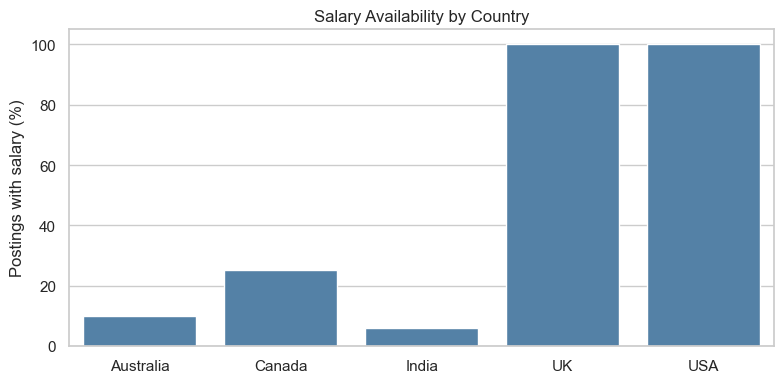

In [8]:
salary_coverage = (
    df.groupby("country")["has_salary"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "postings", "sum": "with_salary", "mean": "coverage"})
)
salary_coverage["coverage_pct"] = salary_coverage["coverage"].mul(100)
display(salary_coverage.drop(columns="coverage").round(2))

plt.figure(figsize=(8, 4))
sns.barplot(data=salary_coverage.reset_index(), x="country", y="coverage_pct", color="steelblue")
plt.title("Salary Availability by Country")
plt.ylabel("Postings with salary (%)")
plt.xlabel("")
plt.tight_layout()
plt.show()

Original salary skewness: 1.085
Log salary skewness: -1.132


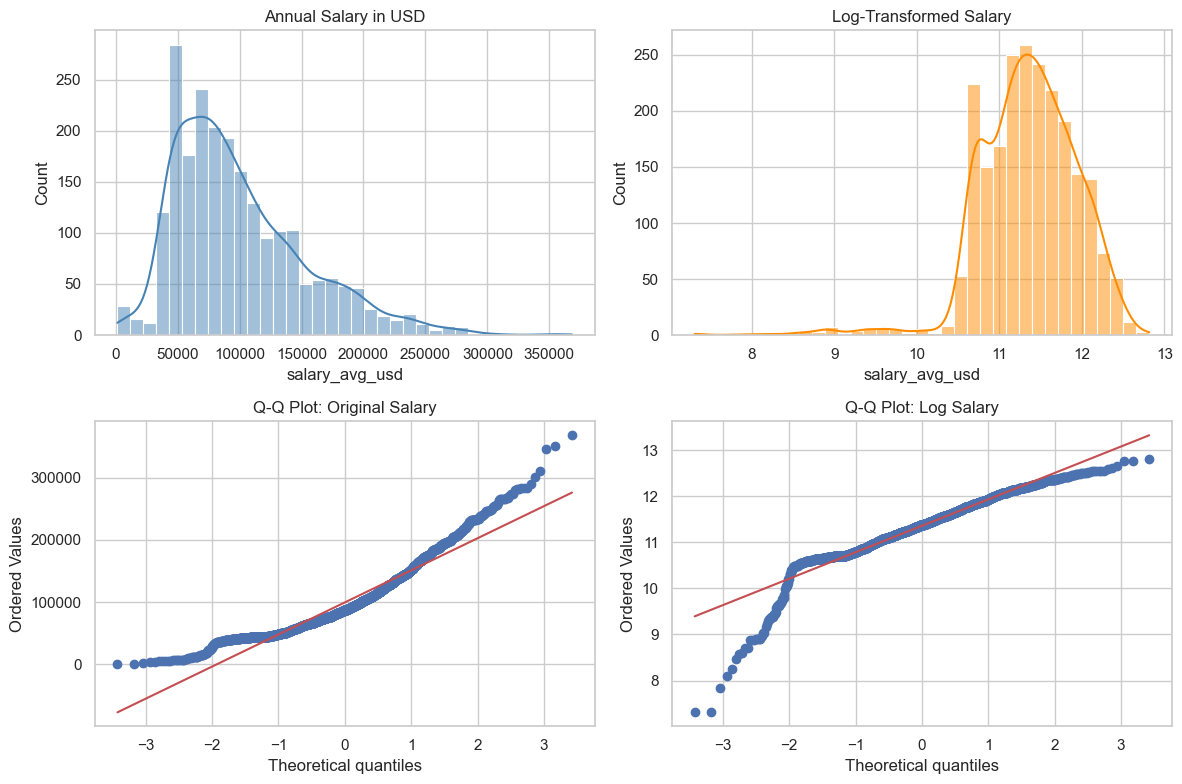

In [9]:
salary = training_data["salary_avg_usd"]
salary_log = np.log1p(salary)

print(f"Original salary skewness: {salary.skew():.3f}")
print(f"Log salary skewness: {salary_log.skew():.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(salary, bins=35, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Annual Salary in USD")
sns.histplot(salary_log, bins=35, kde=True, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Log-Transformed Salary")
stats.probplot(salary, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot: Original Salary")
stats.probplot(salary_log, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot: Log Salary")
plt.tight_layout()
plt.show()

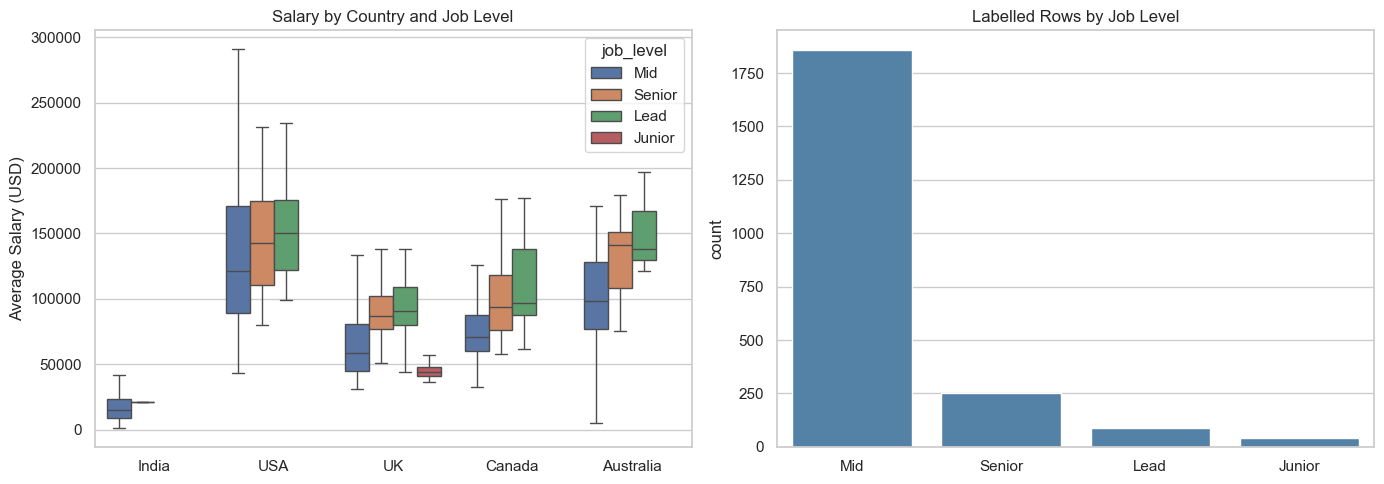

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=training_data, x="country", y="salary_avg_usd", hue="job_level", showfliers=False, ax=axes[0])
axes[0].set_title("Salary by Country and Job Level")
axes[0].set_ylabel("Average Salary (USD)")
axes[0].set_xlabel("")

level_order = training_data["job_level"].value_counts().index
sns.countplot(data=training_data, x="job_level", order=level_order, color="steelblue", ax=axes[1])
axes[1].set_title("Labelled Rows by Job Level")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

### Job-role mix by country

The raw `job_title` field has too many unique titles for a readable grouped chart. `search_keyword` is the dataset's cleaned role category, so it is used as the beginner-friendly version of the requested country-by-job-title view.

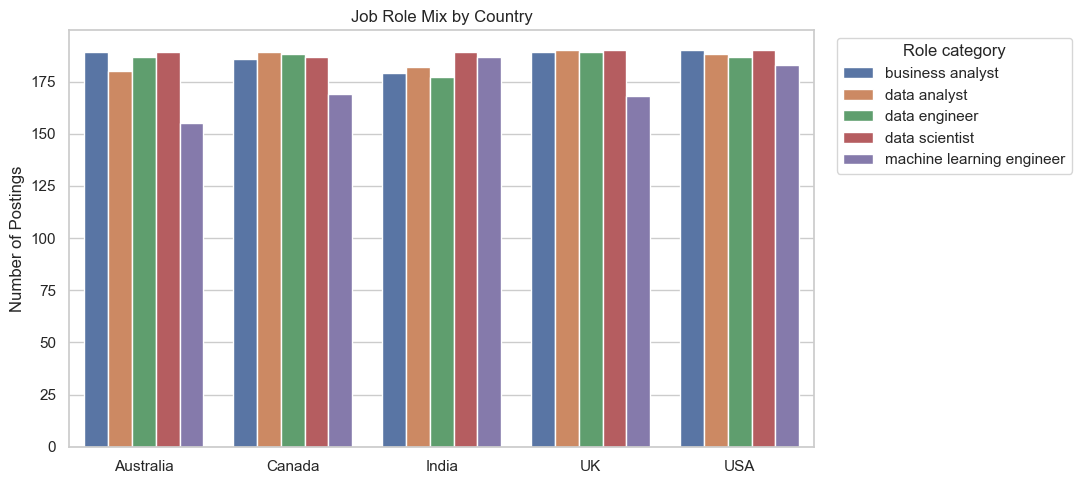

In [11]:
role_mix = (
    df.groupby(["country", "search_keyword"])
    .size()
    .reset_index(name="postings")
)

plt.figure(figsize=(11, 5))
sns.barplot(data=role_mix, x="country", y="postings", hue="search_keyword")
plt.title("Job Role Mix by Country")
plt.ylabel("Number of Postings")
plt.xlabel("")
plt.legend(title="Role category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Pearson correlation

Pearson correlation is suitable for numeric variables. It is not a complete feature-selection method, especially for categorical variables or non-linear models, but it provides a useful first check.

In [12]:
numeric_for_correlation = [
    "salary_avg_usd", "experience_required", "num_skills", "is_remote",
    "is_senior", *skill_columns,
]

correlations = (
    training_data[numeric_for_correlation]
    .assign(is_remote=lambda frame: frame["is_remote"].astype(int))
    .corr()["salary_avg_usd"]
    .drop("salary_avg_usd")
    .sort_values(key=abs, ascending=False)
    .to_frame("pearson_correlation")
)
display(correlations.round(3))

,pearson_correlation
skill_machine_learning,0.35
num_skills,0.26
skill_python,0.10
is_senior,0.10
experience_required,-0.06
skill_sql,0.04
skill_excel,-0.03
skill_power_bi,-0.03
skill_spark,0.02
is_remote,-0.02


### Multicollinearity (VIF)

VIF above 10 suggests that a numeric feature repeats information already contained in other features. Here, `num_skills` is exactly the sum of the individual skill flags, so using both creates perfect multicollinearity. The final model keeps the more interpretable skill flags and drops `num_skills`.

In [13]:
vif_columns = ["num_skills", *skill_columns]
vif_data = training_data[vif_columns].astype(float)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    vif_values = [
        variance_inflation_factor(vif_data.values, position)
        for position in range(vif_data.shape[1])
    ]

vif_table = pd.DataFrame({"feature": vif_columns, "VIF": vif_values})

skill_sum = training_data[skill_columns].sum(axis=1)
print("Rows where num_skills differs from the sum of skill flags:", (skill_sum != training_data["num_skills"]).sum())
display(vif_table.sort_values("VIF", ascending=False))

Rows where num_skills differs from the sum of skill flags: 0


,feature,VIF
0,num_skills,inf
1,skill_python,inf
2,skill_sql,inf
3,skill_spark,inf
4,skill_aws,inf
5,skill_excel,inf
6,skill_machine_learning,inf
7,skill_power_bi,inf
8,skill_tableau,inf


## 7. Prepare data for modelling

The final feature list intentionally excludes:

- `salary_min`, `salary_max`, `salary_avg`, and `salary_range` because they leak the target;
- `is_senior` because it is an exact simplification of `job_level`;
- `num_skills` because it is the sum of the individual skill flags in this dataset.

We keep the four original job-level categories for prediction. The Standard/Premium grouping is used later for segment reporting.

In [14]:
categorical_features = [
    "country", "job_level", "is_remote", "search_keyword",
    "degree_required", "experience_tier",
]
numeric_features = ["experience_missing", *skill_columns]
model_features = categorical_features + numeric_features

X = training_data[model_features].copy()
y = training_data["salary_avg_usd"].copy()

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=X["country"],
)

print("Development rows:", len(X_dev))
print("Untouched test rows:", len(X_test))
display(pd.crosstab(X_dev["country"], columns="development"))
display(pd.crosstab(X_test["country"], columns="test"))

Development rows: 1790
Untouched test rows: 448


col_0,development
country,
Australia,71
Canada,186
India,42
UK,741
USA,750


col_0,test
country,
Australia,18
Canada,46
India,11
UK,185
USA,188


In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features),
])

# The development folds are stratified by country.
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_folds = list(cv_splitter.split(X_dev, X_dev["country"]))

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

## 8. Compare the three required baseline models

Cross-validation is performed only on the development data. MAE is the main selection metric because it matches the business benchmark. Lower MAE and RMSE are better; higher R² is better.

In [16]:
baseline_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=150, random_state=RANDOM_STATE, n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

baseline_pipelines = {}
baseline_rows = []

for name, model in baseline_models.items():
    pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", model),
    ])
    baseline_pipelines[name] = pipeline
    result = cross_validate(
        pipeline, X_dev, y_dev, cv=cv_folds, scoring=scoring, n_jobs=-1
    )
    baseline_rows.append({
        "Model": name,
        "CV_MAE": -result["test_MAE"].mean(),
        "CV_RMSE": -result["test_RMSE"].mean(),
        "CV_R2": result["test_R2"].mean(),
        "MAE_SD": (-result["test_MAE"]).std(),
    })

baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values("CV_MAE")
    .reset_index(drop=True)
)
display(baseline_results.round(2))

,Model,CV_MAE,CV_RMSE,CV_R2,MAE_SD
0,Gradient Boosting,"22,790.21","32,464.55",0.63,629.44
1,Random Forest,"23,180.97","33,376.73",0.60,625.71
2,Linear Regression,"23,823.44","33,604.91",0.60,995.89


## 9. Check whether engineered features help

This small ablation test adds feature groups one at a time. It answers which engineered features improve cross-validated R² without using the final test set.

In [17]:
def build_preprocessor(feature_list):
    categorical = [column for column in feature_list if column in categorical_features]
    numeric = [column for column in feature_list if column not in categorical]
    return ColumnTransformer([
        ("categorical", clone(categorical_pipeline), categorical),
        ("numeric", clone(numeric_pipeline), numeric),
    ])


core_features = ["country", "job_level", "is_remote", "search_keyword"]
feature_sets = {
    "Core": core_features,
    "Core + num_skills": core_features + ["num_skills"],
    "Core + skill flags": core_features + skill_columns,
    "All chosen features": model_features,
}

ablation_rows = []
for label, features in feature_sets.items():
    estimator = Pipeline([
        ("preprocess", build_preprocessor(features)),
        ("model", RandomForestRegressor(
            n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=1
        )),
    ])
    result = cross_validate(
        estimator,
        training_data.loc[X_dev.index, features],
        y_dev,
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1,
    )
    ablation_rows.append({
        "Feature set": label,
        "CV_MAE": -result["test_MAE"].mean(),
        "CV_R2": result["test_R2"].mean(),
    })

ablation_results = pd.DataFrame(ablation_rows).sort_values("CV_MAE")
display(ablation_results.round(3))

,Feature set,CV_MAE,CV_R2
0,Core,"22,787.72",0.62
1,Core + num_skills,"22,866.62",0.61
3,All chosen features,"22,903.48",0.61
2,Core + skill flags,"23,005.12",0.61


## 10. Hyperparameter diagnostics and tuning

### Where tuning is required

- **Ridge Regression:** tune `alpha`, which controls regularisation strength.
- **Random Forest:** tune tree count, maximum depth, and minimum leaf size. The depth diagnostic checks when the training/validation gap becomes large.
- **Gradient Boosting:** tune tree count, learning rate, and tree depth.

The final GridSearchCV is applied to whichever non-linear baseline has the lowest development CV MAE. Linear Regression has no meaningful hyperparameters, so Ridge is tuned separately.

The untouched test set is still locked at this point.

In [18]:
# Ridge alpha tuning
ridge_pipeline = Pipeline([
    ("preprocess", clone(preprocessor)),
    ("model", Ridge()),
])

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": [0.01, 0.1, 1, 10, 100, 1_000]},
    scoring="neg_mean_absolute_error",
    cv=cv_folds,
    n_jobs=-1,
)
ridge_search.fit(X_dev, y_dev)

print("Best Ridge alpha:", ridge_search.best_params_["model__alpha"])
print(f"Best Ridge CV MAE: ${-ridge_search.best_score_:,.2f}")

Best Ridge alpha: 10
Best Ridge CV MAE: $23,756.80


,max_depth,train_MAE,validation_MAE,gap
0,3,"25,553.76","25,974.13",420.36
1,5,"21,884.17","23,111.40","1,227.24"
2,7,"20,603.90","22,783.23","2,179.33"
3,10,"19,629.81","22,903.48","3,273.67"
4,15,"19,233.48","23,154.37","3,920.89"
5,20,"19,210.01","23,196.98","3,986.97"


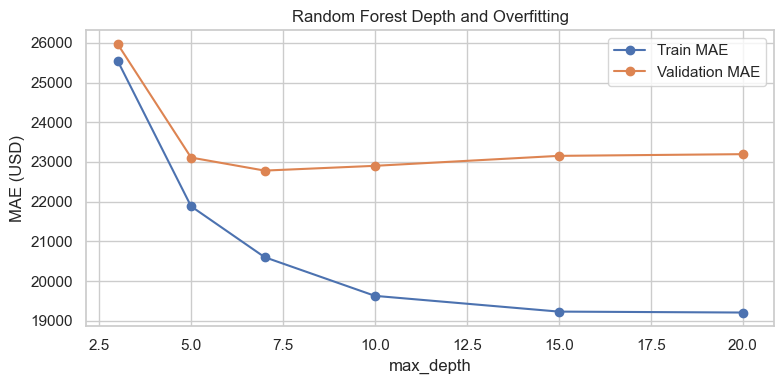

In [19]:
# Random Forest depth diagnostic
depth_rows = []
for depth in [3, 5, 7, 10, 15, 20]:
    depth_pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=depth,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )),
    ])
    result = cross_validate(
        depth_pipeline,
        X_dev,
        y_dev,
        cv=cv_folds,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1,
    )
    train_mae = -result["train_score"].mean()
    validation_mae = -result["test_score"].mean()
    depth_rows.append({
        "max_depth": depth,
        "train_MAE": train_mae,
        "validation_MAE": validation_mae,
        "gap": validation_mae - train_mae,
    })

depth_results = pd.DataFrame(depth_rows)
display(depth_results.round(2))

plt.figure(figsize=(8, 4))
plt.plot(depth_results["max_depth"], depth_results["train_MAE"], marker="o", label="Train MAE")
plt.plot(depth_results["max_depth"], depth_results["validation_MAE"], marker="o", label="Validation MAE")
plt.title("Random Forest Depth and Overfitting")
plt.xlabel("max_depth")
plt.ylabel("MAE (USD)")
plt.legend()
plt.tight_layout()
plt.show()

### Check whether log-transforming the target helps prediction

The distribution became more symmetric after `log1p`, but predictive performance must still be checked in USD. `TransformedTargetRegressor` applies the log during fitting and converts predictions back to dollars automatically.

,Target approach,CV_MAE_USD,CV_RMSE_USD,CV_R2
1,Log target,"22,154.57","32,526.55",0.63
0,Original target,"22,790.21","32,516.37",0.63


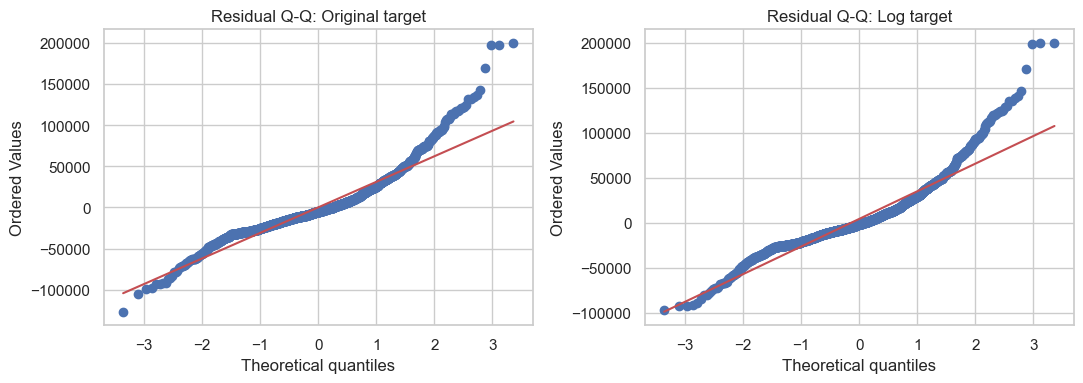

Selected baseline model: Gradient Boosting
Use log target: True


In [20]:
tree_results = baseline_results[baseline_results["Model"].isin(["Random Forest", "Gradient Boosting"])]
selected_model_name = tree_results.iloc[0]["Model"]
selected_pipeline = baseline_pipelines[selected_model_name]

log_pipeline = TransformedTargetRegressor(
    regressor=clone(selected_pipeline),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)

target_rows = []
target_predictions = {}
for target_name, estimator in {
    "Original target": clone(selected_pipeline),
    "Log target": log_pipeline,
}.items():
    predictions = cross_val_predict(
        estimator, X_dev, y_dev, cv=cv_folds, n_jobs=-1
    )
    target_predictions[target_name] = predictions
    target_rows.append({
        "Target approach": target_name,
        "CV_MAE_USD": mean_absolute_error(y_dev, predictions),
        "CV_RMSE_USD": mean_squared_error(y_dev, predictions) ** 0.5,
        "CV_R2": r2_score(y_dev, predictions),
    })

target_results = pd.DataFrame(target_rows).sort_values("CV_MAE_USD")
display(target_results.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, target_name in zip(axes, ["Original target", "Log target"]):
    residuals = y_dev - target_predictions[target_name]
    stats.probplot(residuals, dist="norm", plot=axis)
    axis.set_title(f"Residual Q-Q: {target_name}")
plt.tight_layout()
plt.show()

use_log_target = target_results.iloc[0]["Target approach"] == "Log target"
print("Selected baseline model:", selected_model_name)
print("Use log target:", use_log_target)

In [21]:
# Tune the best tree model with a small, understandable grid.
if selected_model_name == "Random Forest":
    base_pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
    ])
    model_grid = {
        "model__n_estimators": [150, 300],
        "model__max_depth": [7, 12, None],
        "model__min_samples_leaf": [1, 3],
    }
else:
    base_pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ])
    model_grid = {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.07, 0.10],
        "model__max_depth": [2, 3],
    }

if use_log_target:
    estimator_to_tune = TransformedTargetRegressor(
        regressor=base_pipeline,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )
    parameter_grid = {f"regressor__{key}": value for key, value in model_grid.items()}
else:
    estimator_to_tune = base_pipeline
    parameter_grid = model_grid

grid_search = GridSearchCV(
    estimator=estimator_to_tune,
    param_grid=parameter_grid,
    scoring="neg_mean_absolute_error",
    cv=cv_folds,
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_dev, y_dev)

print("Best parameters:")
display(grid_search.best_params_)
print(f"Best tuning CV MAE: ${-grid_search.best_score_:,.2f}")

Best parameters:


{'regressor__model__learning_rate': 0.03,
 'regressor__model__max_depth': 3,
 'regressor__model__n_estimators': 200}

Best tuning CV MAE: $22,139.12


## 11. Final untouched-test evaluation

Only now do we use the 20% test set. This produces the honest final performance estimate. We do not tune again after seeing these results.

In [22]:
best_model = grid_search.best_estimator_
test_predictions = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = mean_squared_error(y_test, test_predictions) ** 0.5
test_r2 = r2_score(y_test, test_predictions)

final_metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Test result": [test_mae, test_rmse, test_r2],
})
display(final_metrics.round(3))

improvement_vs_legacy = LEGACY_MAE - test_mae
print(f"Legacy MAE: ${LEGACY_MAE:,.0f}")
print(f"Final test MAE: ${test_mae:,.2f}")
print(f"Difference vs legacy: ${improvement_vs_legacy:,.2f}")

if test_mae < INDUSTRY_MAE:
    recommendation = "Meets the $8,000 industry target; validate operationally before deployment."
elif test_mae < LEGACY_MAE:
    recommendation = "Improves on the legacy model but misses the industry target; pilot with monitoring."
else:
    recommendation = "Does not beat the legacy model; do not deploy yet. Improve data quality and features."

print("Recommendation:", recommendation)

,Metric,Test result
0,MAE,"21,679.08"
1,RMSE,"31,813.45"
2,R²,0.67


Legacy MAE: $18,500
Final test MAE: $21,679.08
Difference vs legacy: $-3,179.08
Recommendation: Does not beat the legacy model; do not deploy yet. Improve data quality and features.


## 12. Residual bias by country, job level, and salary segment

A positive residual means the model underpredicted salary. A negative residual means it overpredicted. Grouped results show where errors are systematic.

In [23]:
test_diagnostics = training_data.loc[X_test.index, [
    "job_id", "country", "job_level", "salary_segment"
]].copy()
test_diagnostics["actual_salary"] = y_test
test_diagnostics["predicted_salary"] = test_predictions
test_diagnostics["residual"] = (
    test_diagnostics["actual_salary"] - test_diagnostics["predicted_salary"]
)
test_diagnostics["absolute_error"] = test_diagnostics["residual"].abs()

country_bias = (
    test_diagnostics.groupby("country")
    .agg(
        rows=("job_id", "count"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .sort_values("mean_residual", ascending=False)
)

level_bias = (
    test_diagnostics.groupby("job_level")
    .agg(
        rows=("job_id", "count"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
    )
    .sort_values("mean_residual", ascending=False)
)

segment_accuracy = (
    test_diagnostics.groupby("salary_segment")
    .agg(rows=("job_id", "count"), MAE=("absolute_error", "mean"))
    .sort_values("MAE")
)

print("Bias by country")
display(country_bias.round(2))
print("Bias by job level")
display(level_bias.round(2))
print("Accuracy by Standard/Premium segment")
display(segment_accuracy.round(2))

Bias by country


,rows,MAE,mean_residual
country,,,
USA,188,"25,783.15","11,035.77"
Australia,18,"30,966.75","10,649.10"
Canada,46,"18,967.62","7,226.80"
UK,185,"18,180.04","2,869.65"
India,11,"6,525.18",747.23


Bias by job level


,rows,MAE,mean_residual
job_level,,,
Lead,20,"25,840.57","15,150.30"
Mid,372,"21,937.32","7,146.20"
Junior,6,"10,608.93","5,339.77"
Senior,50,"19,421.64","2,890.27"


Accuracy by Standard/Premium segment


,rows,MAE
salary_segment,,
Premium,70,"21,255.62"
Standard,378,"21,757.50"


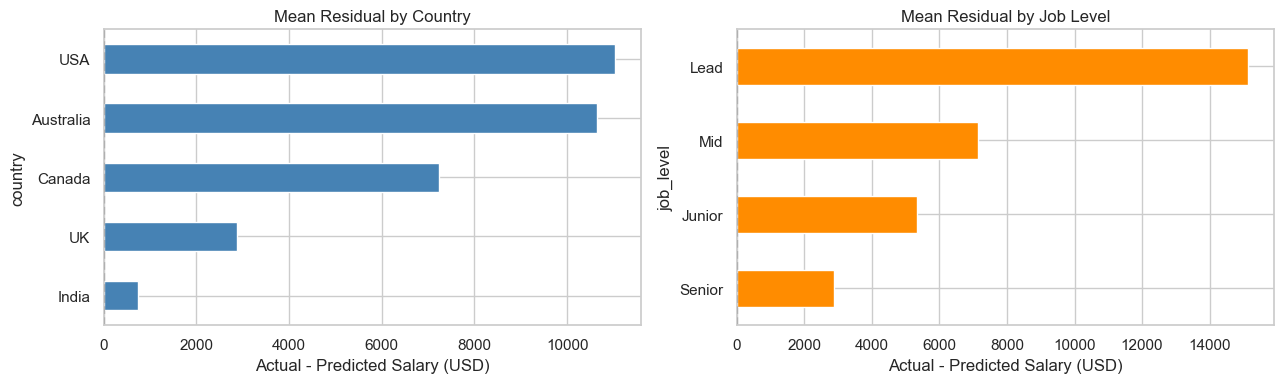

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
country_bias.sort_values("mean_residual")["mean_residual"].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Mean Residual by Country")
axes[0].set_xlabel("Actual - Predicted Salary (USD)")

level_bias.sort_values("mean_residual")["mean_residual"].plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Mean Residual by Job Level")
axes[1].set_xlabel("Actual - Predicted Salary (USD)")
plt.tight_layout()
plt.show()

## 13. Feature importance

Permutation importance measures how much test-set MAE worsens when one input column is shuffled. It is calculated on the held-out test set, so it is less optimistic than measuring importance on training data.

,feature,importance,importance_sd
0,country,"22,297.80","1,533.77"
1,search_keyword,"12,604.92",787.64
2,degree_required,"1,782.34",174.64
3,job_level,"1,247.53",234.99
4,skill_python,508.72,134.04
5,skill_spark,212.51,116.04
6,is_remote,211.26,142.90
7,skill_excel,117.31,27.95
8,skill_machine_learning,98.82,53.44
9,skill_aws,20.42,33.91


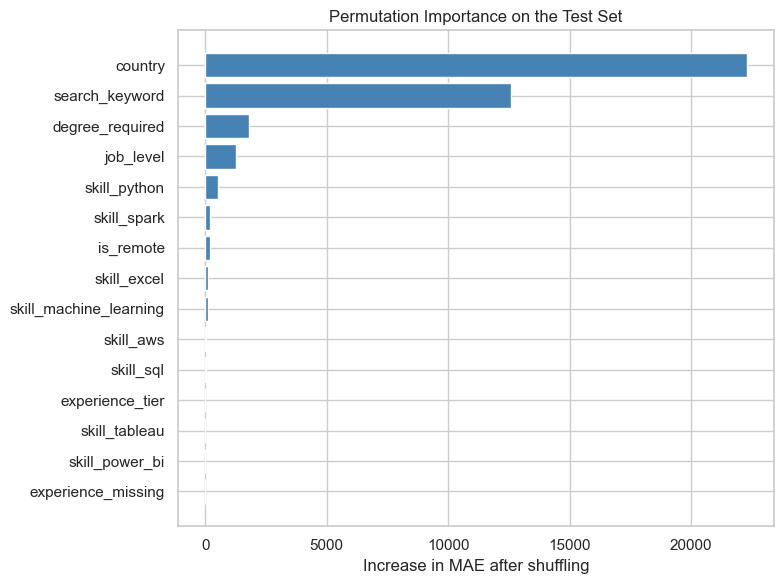

In [25]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_table = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance": importance.importances_mean,
        "importance_sd": importance.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance_table.round(2))

plot_data = importance_table.sort_values("importance")
plt.figure(figsize=(8, 6))
plt.barh(plot_data["feature"], plot_data["importance"], color="steelblue")
plt.title("Permutation Importance on the Test Set")
plt.xlabel("Increase in MAE after shuffling")
plt.tight_layout()
plt.show()

## 14. Refit and create predictions for missing-salary rows

After evaluation, the selected settings are refitted on all labelled data. Predictions for the scoring pool are saved, but they should be treated cautiously because salary availability is highly uneven across countries.

In [26]:
production_model = clone(best_model)
production_model.fit(X, y)

scoring_output = scoring_pool[[
    "job_id", "job_title", "company", "country", "job_level",
    "salary_unit_suspect", "salary_below_10k_review",
]].copy()
scoring_output["predicted_salary_usd"] = production_model.predict(
    scoring_pool[model_features]
)

prediction_path = OUTPUT_DIR / "talentpulse_salary_predictions.csv"
scoring_output.to_csv(prediction_path, index=False)

print(f"Saved {len(scoring_output):,} predictions to: {prediction_path}")
display(scoring_output.head())

Saved 2,359 predictions to: C:\Users\tatej\OneDrive\Documents\Final Capstone Project\output\talentpulse_salary_predictions.csv


,job_id,job_title,company,country,job_level,salary_unit_suspect,salary_below_10k_review,predicted_salary_usd
0,5710345523,data scientist,Empnéo ICT,India,Mid,False,False,"17,048.88"
1,5676535670,data scientist,ADM,India,Mid,False,False,"14,196.60"
2,5705677339,data scientist,v4c.ai,India,Mid,False,False,"14,227.69"
3,5689758521,data scientist,Kotak Mahindra Bank,India,Mid,False,False,"17,048.88"
4,5709942304,data scientist,Whitefield Careers,India,Mid,False,False,"14,796.36"


In [27]:
# Export a short benchmarking memo for the project submission.
most_under_country = country_bias["mean_residual"].idxmax()
most_under_level = level_bias["mean_residual"].idxmax()
top_features = ", ".join(importance_table.head(3)["feature"].tolist())

memo = f'''# TalentPulse Salary Benchmarking Memo

## Decision

{recommendation}

## Final untouched-test performance

- Selected model: {selected_model_name} (tuned with 5-fold GridSearchCV)
- Log-transformed target used: {use_log_target}
- MAE: ${test_mae:,.2f}
- RMSE: ${test_rmse:,.2f}
- R²: {test_r2:.3f}
- Legacy MAE benchmark: ${LEGACY_MAE:,.0f}
- Industry MAE target: ${INDUSTRY_MAE:,.0f}

## Error patterns

- Highest mean underprediction by country: {most_under_country}
- Highest mean underprediction by job level: {most_under_level}
- Leading permutation-importance features: {top_features}

## Required next actions

1. Add salary-period metadata and validate local currency/unit conversions.
2. Collect more labelled salaries in countries with low salary coverage.
3. Add stronger role/title and location features without leaking salary fields.
4. Re-evaluate on newer postings and monitor country/job-level error gaps.
'''

memo_path = OUTPUT_DIR / "talentpulse_benchmarking_memo.md"
memo_path.write_text(memo, encoding="utf-8")
print(f"Saved benchmarking memo to: {memo_path}")

Saved benchmarking memo to: C:\Users\tatej\OneDrive\Documents\Final Capstone Project\output\talentpulse_benchmarking_memo.md


## 15. Final interpretation and next steps

Use the executed results above to write the final portfolio summary. It should state:

- which model and target treatment were selected;
- the final test MAE, RMSE, and R²;
- whether the model beat the $18,500 legacy MAE and the $8,000 industry target;
- which country/job level had the strongest underprediction;
- how Standard and Premium segment MAE differed; and
- the most important features.

### Important limitation

Salary labels are not missing evenly: the USA and UK have far higher salary coverage than several other countries. This means the training data may not represent the scoring pool. Before deployment, TalentPulse should obtain salary-period/currency metadata, review suspicious units, collect more labelled salaries for low-coverage countries, and validate fairness and stability on newer job postings.